# Coppuccino on a Galactic Binary Posterior

This notebook fits a copula normalizing flow to MCMC posterior samples from a galactic binary gravitational-wave source (LDC2A challenge, source #7).

1. Load the posterior samples (8 source parameters)
2. Fit a copula normalizing flow
3. Sample from the fitted flow and compare marginals
4. Corner plot of the full 8D posterior
5. Compare pairwise correlations
6. Evaluate log probabilities
7. Save and load the model

In [1]:
import numpy as np
import pandas as pd
import corner
from matplotlib import pyplot as plt
from coppuccino import normalizing_flows_fit, sample, log_prob, save_flow, load_flow

## 1. Load galactic binary data



In [2]:
posterior = pd.read_feather("./data/LDC2A_00000007_posterior.feather")

params = [
    "Frequency",
    "Frequency Derivative",
    "Amplitude",
    "Ecliptic Longitude",
    "sinlat",
    "cosinc",
    "Initial Phase",
    "Polarization",
]
data = posterior[params].to_numpy()
n_samples = data.shape[0]

print(f"Data shape: {data.shape}")
posterior.head()

Data shape: (3600, 8)


,Group ID,Confidence,SNR,Amplitude,Frequency,Frequency Derivative,Initial Phase,cosinc,Polarization,Ecliptic Longitude,sinlat,Ecliptic Latitude,coslat,Inclination,Parent,opt_snr
0,7.0,1.0,49.413277,4.919698e-21,0.000571,2.178367e-16,0.012636,-0.406781,1.811550,3.650015,-0.296126,-0.300634,-0.296126,1.989724,None,47.567859
1,7.0,1.0,49.728308,5.375559e-21,0.000571,5.545693e-17,3.072001,-0.345436,0.202917,3.662744,-0.296894,-0.301438,-0.296894,1.923499,None,47.906776
2,7.0,1.0,50.779878,5.656702e-21,0.000571,7.665149e-17,3.130777,-0.321993,0.210332,3.672274,-0.305166,-0.310113,-0.305166,1.898630,None,48.921208
3,7.0,1.0,49.316981,5.357642e-21,0.000571,2.188417e-16,3.195048,-0.342568,0.224870,3.643134,-0.344568,-0.351779,-0.344568,1.920445,None,47.505783
4,7.0,1.0,50.094660,5.457370e-21,0.000571,-5.190098e-17,6.166799,-0.340866,1.769427,3.664789,-0.331268,-0.337647,-0.331268,1.918634,None,48.260127


## 2. Fit a copula normalizing flow

In [3]:
flow = normalizing_flows_fit(data, max_epochs=200, rng_seed=42)

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:02<?, ?it/s, train=21.6, val=19.7]

  0%|          | 1/200 [00:02<09:32,  2.88s/it, train=21.6, val=19.7]

  0%|          | 1/200 [00:02<09:32,  2.88s/it, train=18.3, val=16.8]

  0%|          | 1/200 [00:03<09:32,  2.88s/it, train=15.7, val=14.5]

...

 74%|███████▍  | 149/200 [00:14<00:03, 13.19it/s, train=7.14, val=7.48]

 74%|███████▍  | 149/200 [00:14<00:03, 13.19it/s, train=7.13, val=7.51]

 74%|███████▍  | 149/200 [00:14<00:03, 13.19it/s, train=7.13, val=7.54]

 74%|███████▍  | 149/200 [00:14<00:03, 13.19it/s, train=7.13, val=7.54 (Max patience reached)]

 75%|███████▌  | 150/200 [00:14<00:04, 10.53it/s, train=7.13, val=7.54 (Max patience reached)]

## 3. Sample from the flow and compare marginals

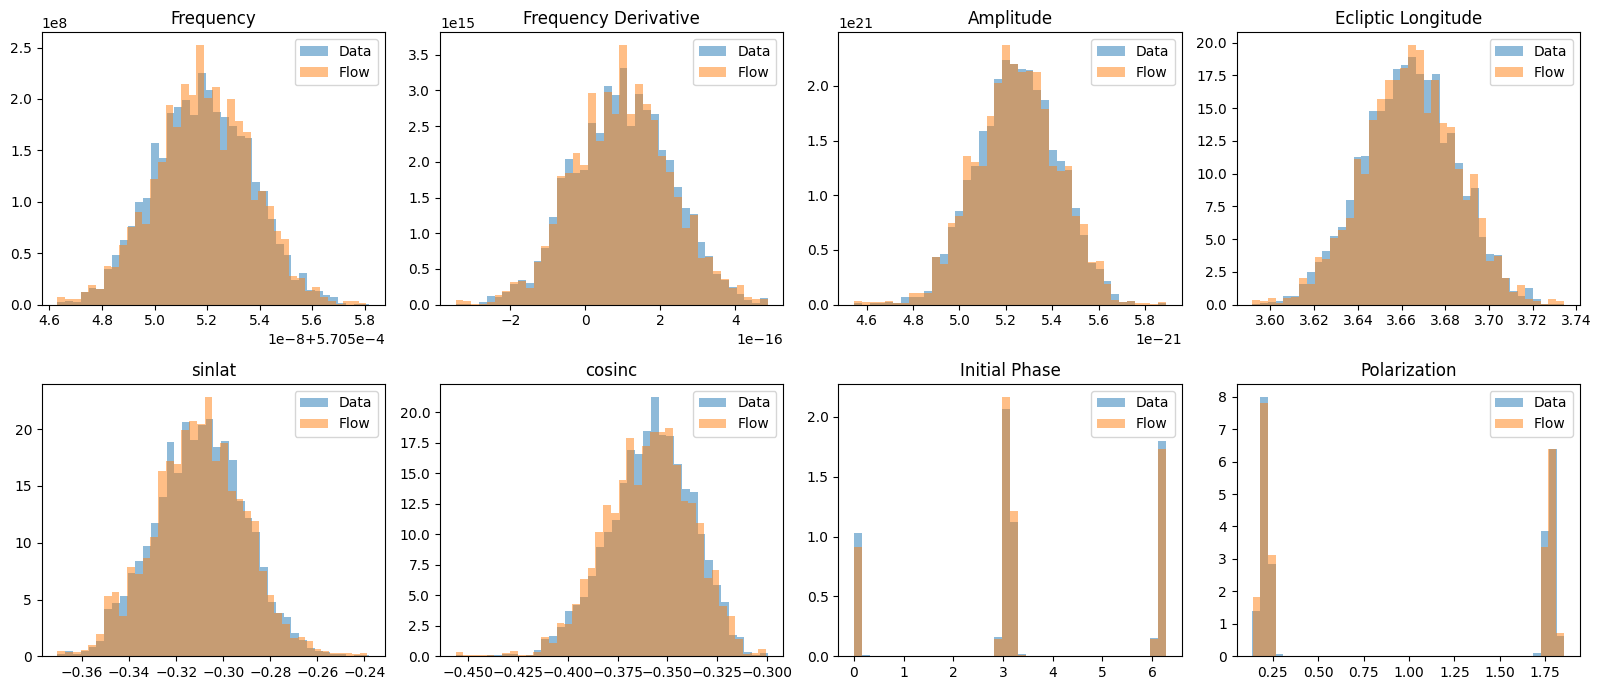

In [4]:
flow_samples = sample(flow, n_samples=n_samples, rng_seed=123)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for i, ax in enumerate(axes.flat):
    ax.hist(data[:, i], bins=40, density=True, alpha=0.5, label="Data")
    ax.hist(flow_samples[:, i], bins=40, density=True, alpha=0.5, label="Flow")
    ax.set_title(params[i])
    ax.legend()
plt.tight_layout()
plt.show()

## 4. Corner plot of the full 8D posterior

Overlay the flow samples on the original posterior across all 8 dimensions.

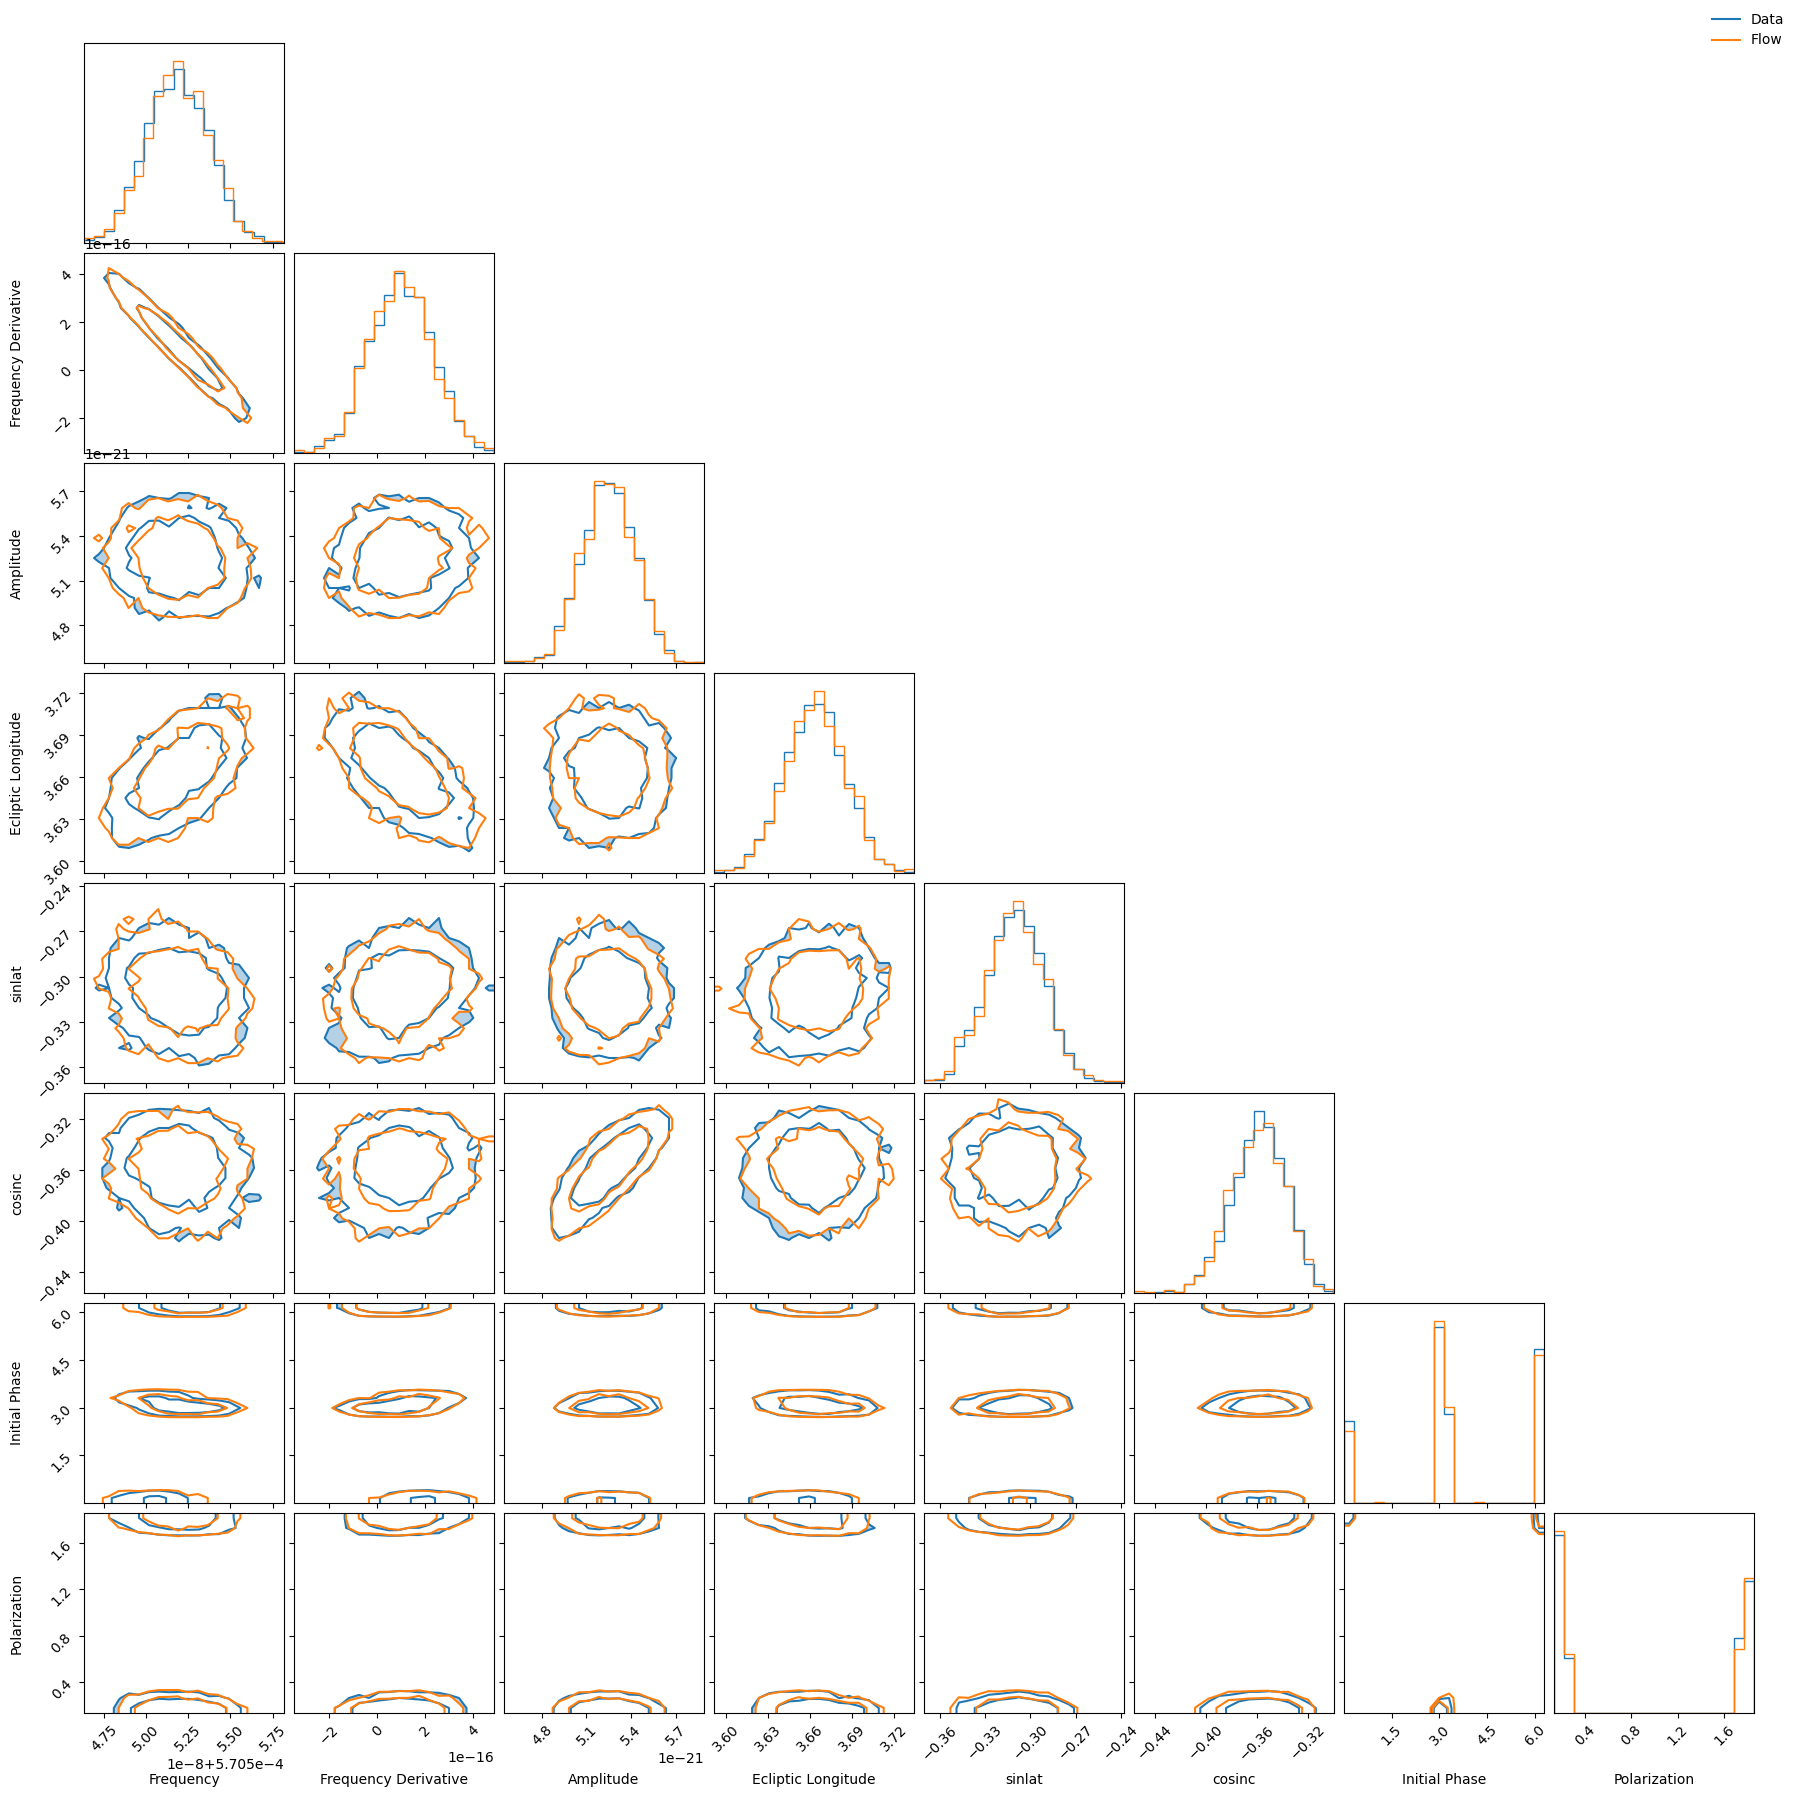

In [5]:
fig = corner.corner(
    data,
    labels=params,
    color="C0",
    hist_kwargs={"density": True},
    plot_datapoints=False,
    plot_density=False,
    fill_contours=True,
    levels=(0.68, 0.95),
)
corner.corner(
    flow_samples,
    labels=params,
    color="C1",
    hist_kwargs={"density": True},
    plot_datapoints=False,
    plot_density=False,
    fill_contours=False,
    levels=(0.68, 0.95),
    fig=fig,
)
fig.legend(
    handles=[
        plt.Line2D([], [], color="C0", label="Data"),
        plt.Line2D([], [], color="C1", label="Flow"),
    ],
    loc="upper right",
    frameon=False,
)
plt.show()

## 5. Compare pairwise correlations

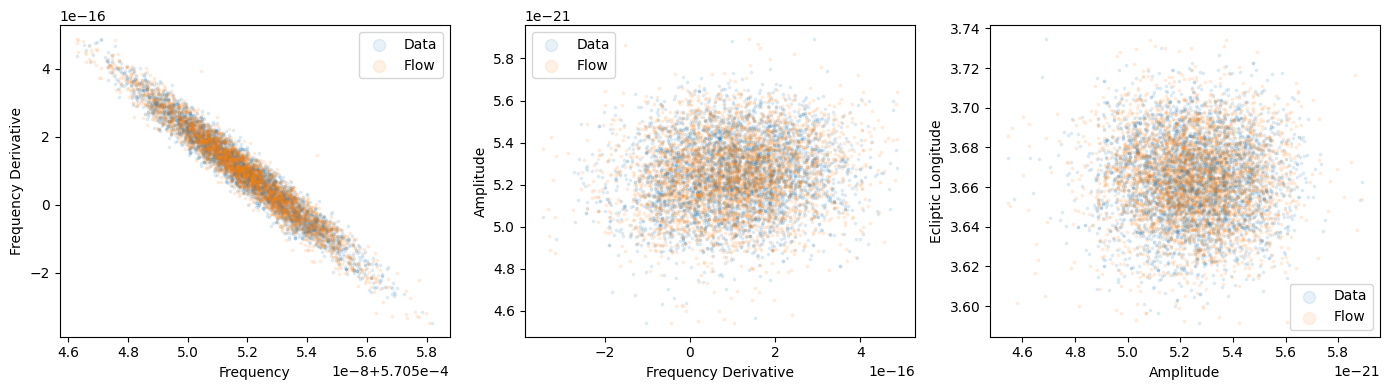

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
pairs = [(0, 1), (1, 2), (2, 3)]
for ax, (i, j) in zip(axes, pairs):
    ax.scatter(data[:, i], data[:, j], alpha=0.1, s=3, label="Data")
    ax.scatter(flow_samples[:, i], flow_samples[:, j], alpha=0.1, s=3, label="Flow")
    ax.set_xlabel(params[i])
    ax.set_ylabel(params[j])
    ax.legend(markerscale=5)
plt.tight_layout()
plt.show()

## 6. Evaluate log probabilities

In [7]:
log_probs = log_prob(flow, data[:100])
print(f"Mean log prob on training data: {np.mean(log_probs):.3f}")
print(f"Std log prob: {np.std(log_probs):.3f}")

Mean log prob on training data: 116.344
Std log prob: 5.169


## 7. Save and load the model

In [8]:
save_flow(flow, "example_flow.pkl")
loaded_flow = load_flow("example_flow.pkl")

# Verify loaded flow produces the same samples
loaded_samples = sample(loaded_flow, n_samples=1000, rng_seed=99)
original_samples = sample(flow, n_samples=1000, rng_seed=99)
print(f"Max difference between original and loaded samples: {np.max(np.abs(loaded_samples - original_samples)):.2e}")

Max difference between original and loaded samples: 0.00e+00
